In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

# Load clean datasets
orders = pd.read_csv('../data/processed/clean_orders.csv')
items = pd.read_csv('../data/processed/clean_order_items.csv')
products = pd.read_csv('../data/processed/clean_products.csv')
reviews = pd.read_csv('../data/processed/clean_reviews.csv')
customers = pd.read_csv('../data/processed/clean_customers.csv')
sellers = pd.read_csv('../data/processed/clean_sellers.csv')
payments = pd.read_csv('../data/processed/clean_payments.csv')

# Ensure timestamp conversions
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

print("Data successfully loaded for Exploratory Data Analysis!")

Data successfully loaded for Exploratory Data Analysis!


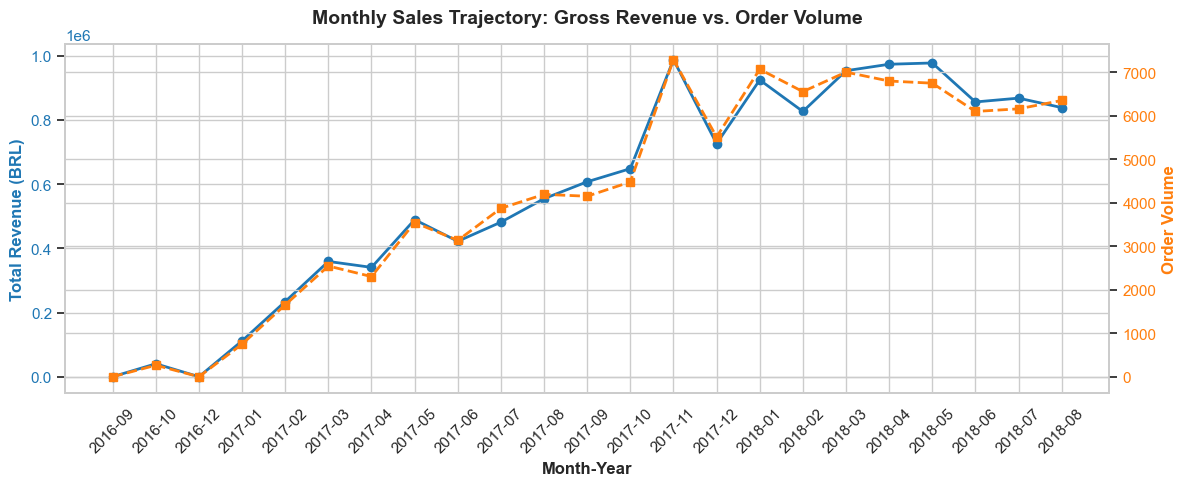

In [3]:
# Module 1: Sales Trends
sales_df = orders.merge(items, on='order_id').query("order_status == 'delivered'")
sales_df['year_month'] = sales_df['order_purchase_timestamp'].dt.to_period('M').astype(str)

monthly_sales = sales_df.groupby('year_month').agg(
    total_revenue=('price', 'sum'),
    order_count=('order_id', 'nunique')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('Month-Year', fontweight='bold')
ax1.set_ylabel('Total Revenue (BRL)', color=color, fontweight='bold')
ax1.plot(monthly_sales['year_month'], monthly_sales['total_revenue'], color=color, marker='o', linewidth=2, label='Revenue')
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45)

ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Order Volume', color=color, fontweight='bold')
ax2.plot(monthly_sales['year_month'], monthly_sales['order_count'], color=color, marker='s', linestyle='--', linewidth=2, label='Orders')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Monthly Sales Trajectory: Gross Revenue vs. Order Volume', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.savefig('../reports/sales_trend.png', dpi=300)
plt.show()

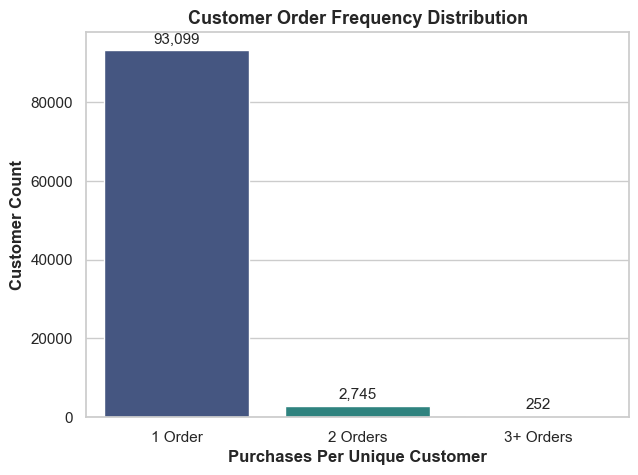

In [4]:
# Module 2: Customer Trends
cust_orders = customers.groupby('customer_unique_id')['customer_id'].count().reset_index()
cust_orders['order_bin'] = cust_orders['customer_id'].apply(lambda x: '1 Order' if x == 1 else ('2 Orders' if x == 2 else '3+ Orders'))

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=cust_orders, x='order_bin', palette='viridis', hue='order_bin', legend=False)
plt.title('Customer Order Frequency Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Purchases Per Unique Customer', fontweight='bold')
plt.ylabel('Customer Count', fontweight='bold')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

plt.savefig('../reports/customer_trends.png', dpi=300)
plt.show()

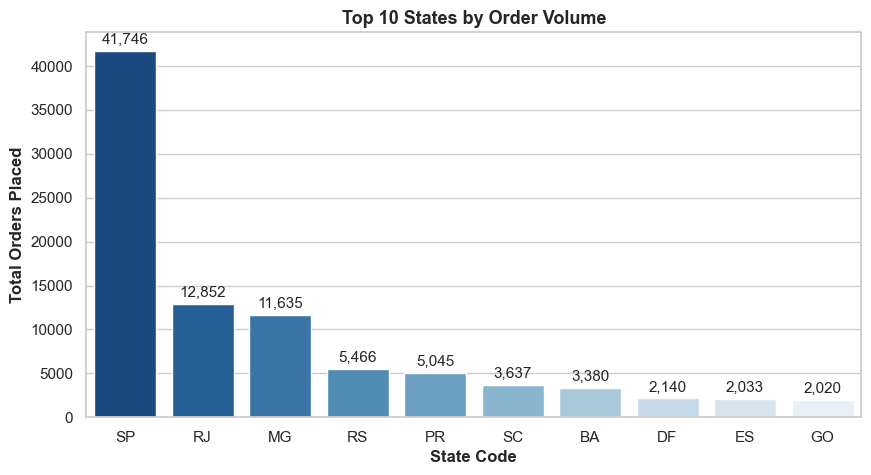

In [5]:
# Module 3: Regional Trends
state_orders = customers['customer_state'].value_counts().head(10).reset_index()
state_orders.columns = ['customer_state', 'order_count']

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=state_orders, x='customer_state', y='order_count', palette='Blues_r', hue='customer_state', legend=False)
plt.title('Top 10 States by Order Volume', fontsize=13, fontweight='bold')
plt.xlabel('State Code', fontweight='bold')
plt.ylabel('Total Orders Placed', fontweight='bold')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

plt.savefig('../reports/regional_trends.png', dpi=300)
plt.show()

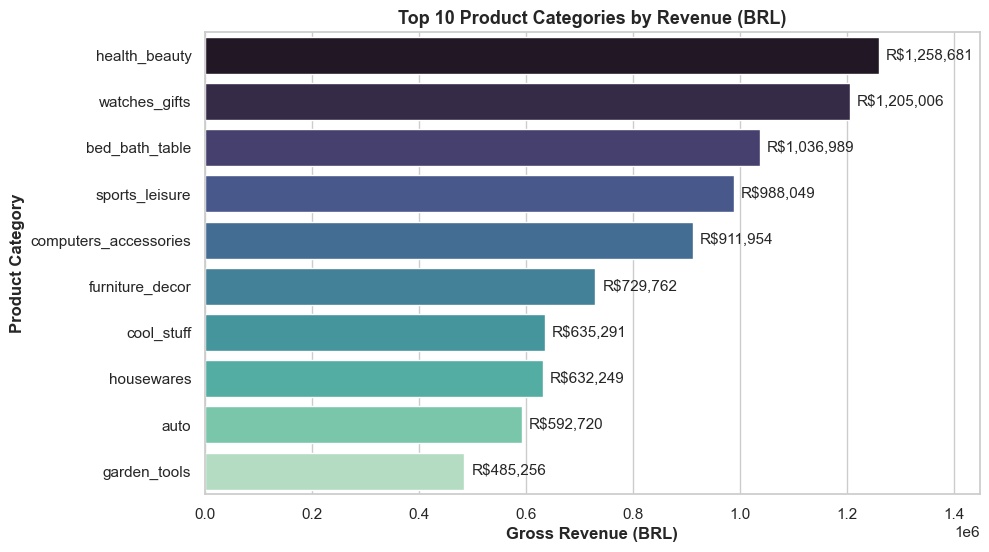

In [6]:
# Module 4: Product Analysis
prod_sales = items.merge(products, on='product_id')
top_categories = prod_sales.groupby('product_category_name_english')['price'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_categories, y='product_category_name_english', x='price', palette='mako', hue='product_category_name_english', legend=False)
plt.title('Top 10 Product Categories by Revenue (BRL)', fontsize=13, fontweight='bold')
plt.xlabel('Gross Revenue (BRL)', fontweight='bold')
plt.ylabel('Product Category', fontweight='bold')

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'R${width:,.0f}', (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.xlim(0, top_categories['price'].max() * 1.15)
plt.savefig('../reports/product_analysis.png', dpi=300)
plt.show()

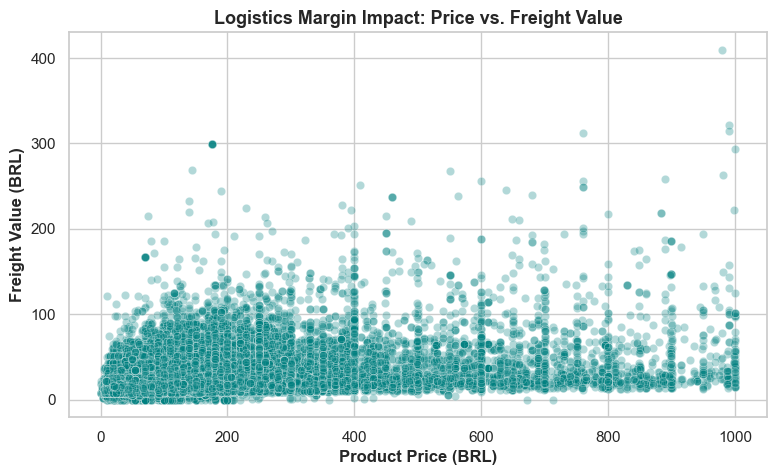

In [7]:
# Module 5: Profit & Cost Analysis
plt.figure(figsize=(9, 5))
sns.scatterplot(data=items[items['price'] < 1000], x='price', y='freight_value', alpha=0.3, color='teal')
plt.title('Logistics Margin Impact: Price vs. Freight Value', fontsize=13, fontweight='bold')
plt.xlabel('Product Price (BRL)', fontweight='bold')
plt.ylabel('Freight Value (BRL)', fontweight='bold')

plt.savefig('../reports/profit_analysis.png', dpi=300)
plt.show()

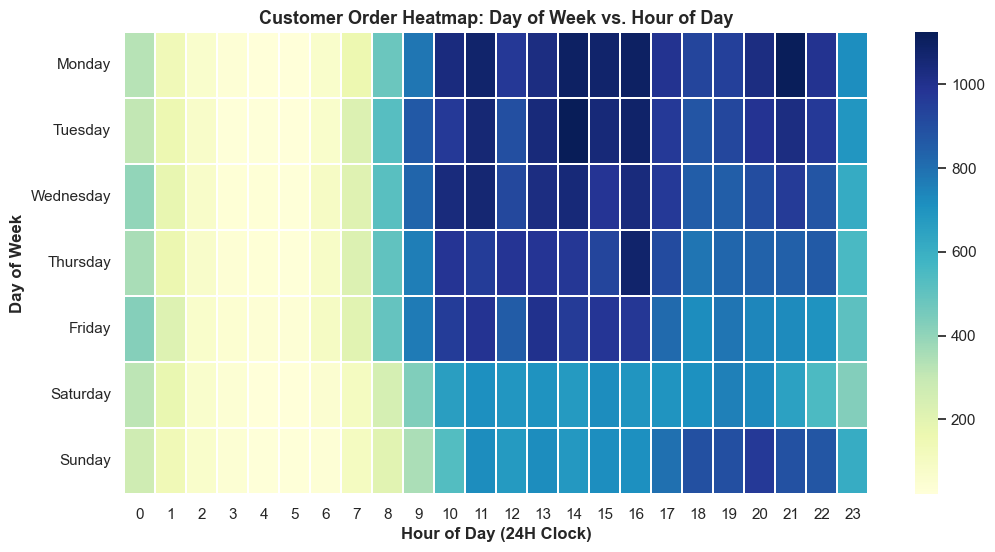

In [8]:
# Module 6: Seasonality Analysis
orders['day_of_week'] = orders['order_purchase_timestamp'].dt.day_name()
orders['hour_of_day'] = orders['order_purchase_timestamp'].dt.hour

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = orders.groupby(['day_of_week', 'hour_of_day']).size().unstack().reindex(day_order)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu', linewidths=0.1)
plt.title('Customer Order Heatmap: Day of Week vs. Hour of Day', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day (24H Clock)', fontweight='bold')
plt.ylabel('Day of Week', fontweight='bold')

plt.savefig('../reports/seasonality.png', dpi=300)
plt.show()

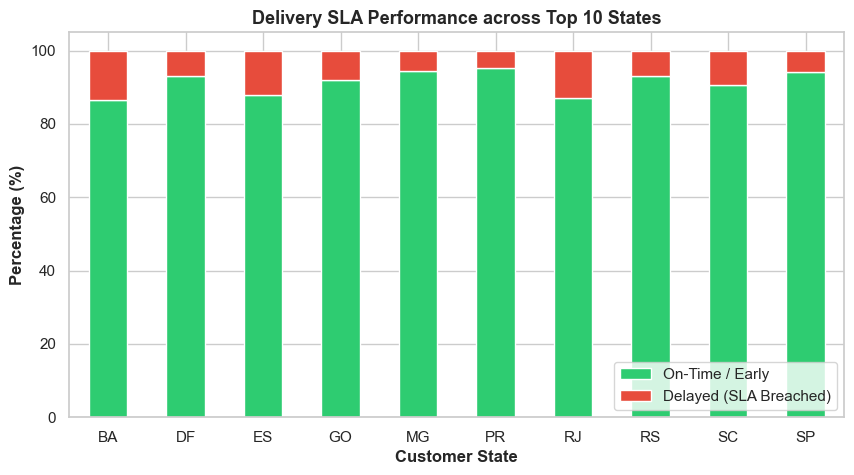

In [9]:
# Module 7: Shipping Analysis
order_cust = orders.merge(customers, on='customer_id')
top_10_states = order_cust['customer_state'].value_counts().head(10).index

sla_df = order_cust[order_cust['customer_state'].isin(top_10_states)]
sla_summary = sla_df.groupby(['customer_state', 'is_delayed']).size().unstack(fill_value=0)
sla_summary_pct = sla_summary.div(sla_summary.sum(axis=1), axis=0) * 100

sla_summary_pct.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(10, 5))
plt.title('Delivery SLA Performance across Top 10 States', fontsize=13, fontweight='bold')
plt.xlabel('Customer State', fontweight='bold')
plt.ylabel('Percentage (%)', fontweight='bold')
plt.legend(['On-Time / Early', 'Delayed (SLA Breached)'], loc='lower right')
plt.xticks(rotation=0)

plt.savefig('../reports/shipping_analysis.png', dpi=300)
plt.show()

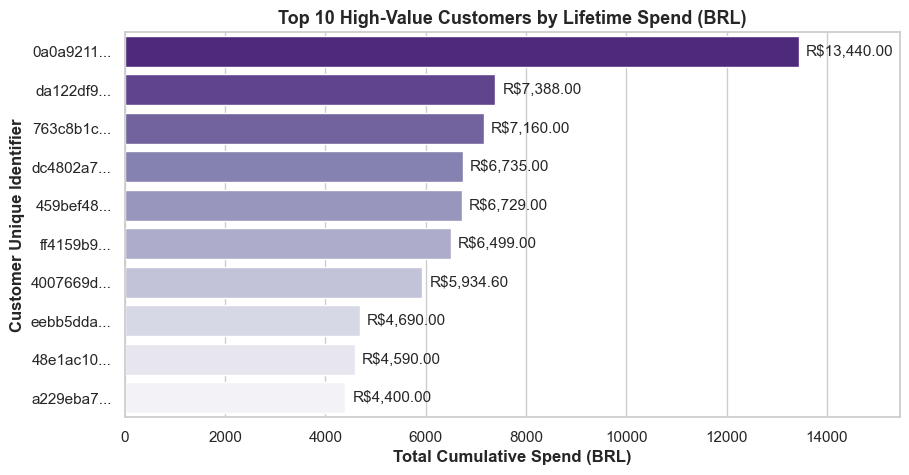

In [10]:
# Module 8: Top Customers Analysis
cust_ltv = sales_df.merge(customers, on='customer_id').groupby('customer_unique_id')['price'].sum().nlargest(10).reset_index()
cust_ltv['customer_short'] = cust_ltv['customer_unique_id'].str[:8] + '...'

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=cust_ltv, x='price', y='customer_short', palette='Purples_r', hue='customer_short', legend=False)
plt.title('Top 10 High-Value Customers by Lifetime Spend (BRL)', fontsize=13, fontweight='bold')
plt.xlabel('Total Cumulative Spend (BRL)', fontweight='bold')
plt.ylabel('Customer Unique Identifier', fontweight='bold')

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'R${width:,.2f}', (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.xlim(0, cust_ltv['price'].max() * 1.15)
plt.savefig('../reports/top_customers.png', dpi=300)
plt.show()

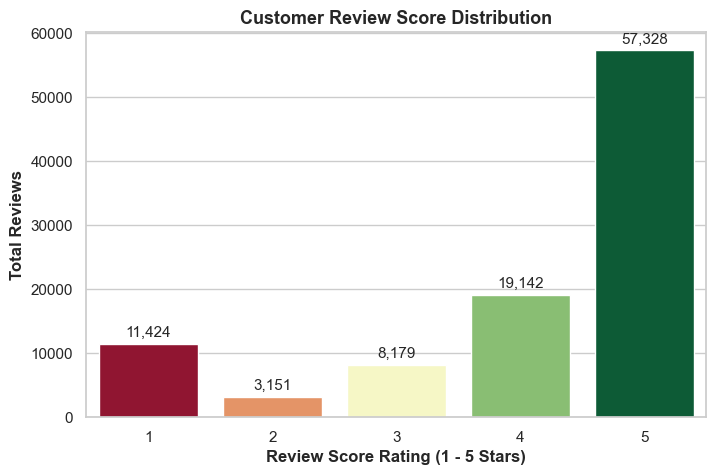

In [11]:
# Module 9: Returns & Order Issues
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=reviews, x='review_score', palette='RdYlGn', hue='review_score', legend=False)
plt.title('Customer Review Score Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Review Score Rating (1 - 5 Stars)', fontweight='bold')
plt.ylabel('Total Reviews', fontweight='bold')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

plt.savefig('../reports/returns_analysis.png', dpi=300)
plt.show()

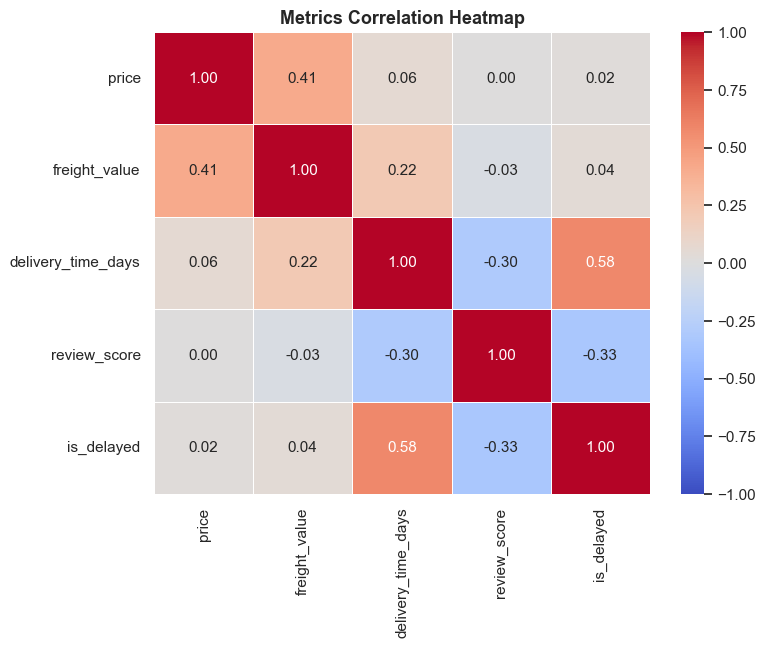

In [12]:
# Module 10: Correlation Heatmap
corr_df = sales_df.merge(reviews, on='order_id')[['price', 'freight_value', 'delivery_time_days', 'review_score', 'is_delayed']]
correlation_matrix = corr_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Metrics Correlation Heatmap', fontsize=13, fontweight='bold')

plt.savefig('../reports/correlation_matrix.png', dpi=300)
plt.show()